# Opinion Survey Analysis

Author: Jennifer Le  
Date: 12/6/24

The purpose of this analysis is to   
1. Examine how opinions on topics like the economy has changed from 2020 to 2024.  
2. Discover interesting trends and correlations such as the correlation between income and religious beliefs.

The data used for this project is from the National Public Opinion Reference surveys (NPORS) conducted by the Pew Reserach Center. 

This survey includes questions on demographics like income, education, and race. It also includes questions about political views, social media use, opinions on the economy, piety and dedication to religious beliefs, and more. Click on the link below to see the 2022 Questionnaire. Navigate to other folders to see questionnaires for other years. 

<a href="https://github.com/JenniferMLe/Opinion-Survey-Analysis/blob/main/Datasets/NPORS-2022/Questionnaire_22.pdf" target="_blank">See questions asked for 2022 study</a>  
<a href="https://www.pewresearch.org/methods/fact-sheet/national-public-opinion-reference-survey-npors/" target="_blank">More information on NPORS</a>  
<a href="https://jennifermle.github.io/Opinion-Survey-Analysis/" 
target="_blank">Click to see graphs (if viewing main.ipynb)</a>

The concept for this project stems from an assignment from Prof. Elena Zheleva's Intro to Data Science class (CS 418), spring 2024.

## Helper functions

In [96]:
import pandas as pd
import plotly.express as px
import numpy as np

def write_to_file(df,file_name='Result_Datasets/result.csv'):
    df.to_csv(file_name, index=False)

# print a list of distinct values from a column in a dataframe
# helps with data cleaning
def get_distinct_values(df, columns,sort_by):
    vals = df[columns].sort_values(by=sort_by).drop_duplicates()
    # print to csv file to see all values since output may be cut if too long
    write_to_file(vals)

def get_count(col):
    # as_index=False doesn't make group labels the index
    df = df_combined.groupby(col, as_index=False)['RESPID'].count()
    df = df.rename(columns={'RESPID':'Count'})
    df = df[df[col] != 'N/A']
    write_to_file(df)
    return df

category_orders = {
    'AGEGRP2':[
        '18-24','25-39','40-59','60-79','80+'],

    'INCOMEGRP':['< $40K','$40-70K','$70-100K','$100K+'],
    
    'EDUCATION':[
        "No schooling completed",
        "Kindergarten",
        "Some High School",
        "High School",
        "Some College",
        "Associate's Degree",
        "Bachelor's Degree",
        "Master's Degree or Higher"
    ]
}

## Importing Data

In [42]:
# Save each .sav as a data frame
df_20 = pd.read_spss("Datasets/NPORS-2020/dataset.sav")
df_21 = pd.read_spss("Datasets/NPORS-2021/dataset.sav")
df_22 = pd.read_spss("Datasets/NPORS-2022/dataset.sav")
df_23 = pd.read_spss("Datasets/NPORS-2023/dataset.sav")
df_24 = pd.read_spss("Datasets/NPORS-2024/dataset.sav")
df_25 = pd.read_spss("Datasets/NPORS-2025/dataset.sav")

# convert .sav to .csv
write_to_file(df_20,"Datasets/NPORS-2020/dataset_20.csv")
write_to_file(df_21,"Datasets/NPORS-2021/dataset_21.csv")
write_to_file(df_22,"Datasets/NPORS-2022/dataset_22.csv")
write_to_file(df_23,"Datasets/NPORS-2023/dataset_23.csv")
write_to_file(df_24,"Datasets/NPORS-2024/dataset_24.csv")
write_to_file(df_25,"Datasets/NPORS-2025/dataset_25.csv")

## Combining Data

In [43]:
# stop number of columns at the end that don't have the year in the column name
def remove_year_from_column_name(dataset, stop):
    list_columns = list(dataset.columns)

    for i in range(0,len(list_columns)-stop):
        list_columns[i] = list_columns[i][:-5]

    dataset.columns = list_columns

# Remove the year from column name to keep naming consistant
remove_year_from_column_name(df_20, 5)
remove_year_from_column_name(df_21, 2)

# ensure columns recording the same data have the same name
# so there aren't duplicate columns when appending datasets
df_20 = df_20.rename(columns={
    'SEXASK':'GENDER', 
    'EDUC_ACS':'EDUCATION'
})

df_23 = df_23.rename(columns={
    'BASEWT':'BASEWEIGHT', 
    'INC_SDT1':'INCOME'
})

df_24 = df_24.rename(columns={
    'BASEWT':'BASEWEIGHT', 
    'INC_SDT1': 'INCOME',
    'SMUSEa' : 'SMUSE_a','SMUSEd' : 'SMUSE_d','SMUSEg' : 'SMUSE_g','SMUSEj' : 'SMUSE_j',
    'SMUSEb' : 'SMUSE_b','SMUSEe' : 'SMUSE_e','SMUSEh' : 'SMUSE_h','SMUSEk' : 'SMUSE_k',
    'SMUSEc' : 'SMUSE_c','SMUSEa' : 'SMUSE_f','SMUSEi' : 'SMUSE_i'
})

df_25 = df_25.rename(columns={
    'BASEWT':'BASEWEIGHT', 
    'INC_SDT1': 'INCOME'
})

# add year columns to all datasets
df_20['YEAR'] = 2020
df_21['YEAR'] = 2021
df_22['YEAR'] = 2022
df_23['YEAR'] = 2023
df_24['YEAR'] = 2024
df_25['YEAR'] = 2025

# Combine (append) all datasets together
df_combined = pd.concat([df_20, df_21, df_22, df_23, df_24, df_25])
print(df_combined.shape)

# Keep relevent columns only
df_combined = df_combined[[
    'RESPID','AGE','AGEGRP','GENDER','RACECMB', # basic demographics
    'INCOME','EDUCATION', 'RELIG', 'PARTY', # other useful demographics 
    'RELIMP', 'PRAY', 'MARITAL', # other features
    'SMUSE_a', 'SMUSE_b', 'SMUSE_c', 'SMUSE_d', 'SMUSE_e', 'SMUSE_f', # social media use
    'SMUSE_g','SMUSE_h','SMUSE_i','SMUSE_j','SMUSE_k',
    'ECON1MOD', 'ECON1BMOD', # we want to study how this changes over time
    'BASEWEIGHT', 'WEIGHT' 
]]


(28469, 123)


## Cleaning Data

In [44]:
# rename columns
df_combined = df_combined.rename(columns={
    'SMUSE_a':'FACEBOOK',
    'SMUSE_b':'YOUTUBE',
    'SMUSE_c':'TWITTER',
    'SMUSE_d':'INSTAGRAM',
    'SMUSE_e':'SNAPCHAT',
    'SMUSE_f':'WHATSAPP',
    'SMUSE_g':'LINKEDIN',
    'SMUSE_h':'PINTEREST',
    'SMUSE_i':'TIKTOK',
    'SMUSE_j':'BEREAL',
    'SMUSE_k':'REDDIT',
    'RACECMB':'RACE'
})

'''
replace values for consistency 
'''
# change n/a to -1 so we can convert age to float
df_combined["AGE"] = df_combined["AGE"].replace({
    "n/a":"-1",
    "98+":"98",
    "":"-1",
    'Refused':"-1"
})

# change column type
df_combined["AGE"] = df_combined["AGE"].astype(float)


df_combined = df_combined.replace({
    r'.*Refused.*':'N/A',
    r'.*Something else.*':'Other',
    'No, don\'t use this':'No',
    'No, don’t use this':'No',
    "Yes, use this":'Yes',
},regex=True)

df_combined['GENDER'] = df_combined['GENDER'].replace({
    "A man":"Male",
    "A woman":"Female",
    "In some other way":"Other"
})

df_combined["RACE"] = df_combined["RACE"].replace({
    r'.*Asian.*':'Asian',
    r'.*Black.*':'Black',
    r'.*other.*':'Other',
    'Mixed race':'Mixed Race'
},regex=True)

df_combined['ECON1MOD'] = df_combined['ECON1MOD'].replace('Only Fair','Only fair')

df_combined["INCOME"] = df_combined["INCOME"].replace({
    r' to less than ':'-',
    r' or more':'+',
    r'Less than':'<',
    r',000':'K',
},regex=True)

df_combined["EDUCATION"] = df_combined["EDUCATION"].replace({
    r'.*11.*':'Some High School',
    r'.*12.*':'Some High School',
    r'.*high school.*':'High School',
    r'.*GED.*':'High School',
    r'.*college.*':'Some College',
    r'.*Associate.*':'Associate\'s Degree',
    r'.*Bachelor.*':'Bachelor\'s Degree',
    r'.*Master.*':'Master\'s Degree or Higher',
    r'.*MD.*':'Master\'s Degree or Higher',
    r'.*Doctorate.*':'Master\'s Degree or Higher'
},regex=True)

df_combined["RELIG"] = df_combined["RELIG"].replace({
    r'.*Mormon.*':'Mormon',
    r'.*Orthodox.*':'Orthodox',
    r'.*Protestant.*':'Protestant'
},regex=True)

df_combined['MARITAL'] = df_combined['MARITAL'].replace({
    "Separated":"Divorced",
    "Never been married":"Never married",
})

categorical_cols = df_combined.select_dtypes(include="category").columns
df_combined[categorical_cols] = df_combined[categorical_cols].astype(str)

write_to_file(df_combined, 'Result_Datasets/combined_dataset.csv')
print(df_combined.shape)


(28469, 27)


## Creating Calculated Columns

In [45]:
'''create calculated columns to group incomes'''
# conditions for each group
conditions = [
    df_combined['INCOME'].isin(['$10K-$20K','$20K-$30K','$30K-$40K','< $10K','< $30K']),
    df_combined['INCOME'].isin(['$40K-$50K','$50K-$60K','$60K-$70K','$50K-$70K']),
    df_combined['INCOME'].isin(['$70K-$100K','$70K-$80K','$70K-$90K','$75K-$100K','$80K-$90K','$90K-$100K']),
    df_combined['INCOME'].isin(['$100K-$150K','$125K-$150K','$150K+'])
]
# corresponding groups for each condition
group = ['< $40K','$40-70K','$70-100K','$100K+']

# insert new column after INCOME
df_combined.insert(
    df_combined.columns.get_loc('INCOME') + 1, # position we want to insert at
    'INCOMEGRP', # name of new column
    np.select(conditions, group, default='N/A') # set value according to conditions 
)

'''create calculated columns to group incomes'''
conditions = [
    (df_combined['AGEGRP'] == '18-24') | ((18 <= df_combined['AGE']) & (df_combined['AGE'] <= 24)),
    (df_combined['AGEGRP'].isin(['25-29','30-34','35-39'])) | ((25 <= df_combined['AGE']) & (df_combined['AGE'] <= 39)),
    (df_combined['AGEGRP'].isin(['40-44','45-49','50-54','55-59'])) | ((40 <= df_combined['AGE']) & (df_combined['AGE'] <= 59)),
    (df_combined['AGEGRP'].isin(['60-64','65-69','70-74','75-79'])) | ((60 <= df_combined['AGE']) & (df_combined['AGE'] <= 79)),
    (df_combined['AGEGRP'] == '80+')| (80 <= df_combined['AGE'])
]
group = ['18-24','25-39','40-59','60-79','80+']

df_combined.insert(
    df_combined.columns.get_loc('AGEGRP') + 1, # position we want to insert at
    'AGEGRP2', # name of new column
    np.select(conditions, group, default='N/A') # set value according to conditions 
)

In [92]:
df = df_combined[['AGE','AGEGRP','AGEGRP2']].sort_values(by='AGE').drop_duplicates()


get_distinct_values(df_combined,['EDUCATION'],'EDUCATION')

## Suvery Participant Demographics

In this section, we will get to know our 2020-2024 survey participants and who they consist of by examining their age, race, gender, income, and education.

In [86]:
# look in distinct_values.csv to see results
get_distinct_values(df_combined,['AGEGRP2'],'AGEGRP2')

fig = px.bar(
    get_count('AGEGRP2'), 
    x = 'AGEGRP2', 
    y = 'Count',
    title = "Demographic Breakdown by Age",
    category_orders = category_orders,
    color_discrete_sequence=px.colors.sequential.Viridis
)
fig.update_xaxes(title="Age").show()

In [87]:
fig = px.bar(
    get_count('RACE'), 
    y='RACE', 
    x='Count',
    title='Demographic Breakdown by Race',
    text_auto='.2s', # put numbers in K format
    color_discrete_sequence=['#ffd525']
    
)
# add subtitle
fig.update_layout(
    annotations=[
        dict(
            x=-0.45, y=-0.20,  # Position below the chart
            text="*Participants can select more than 1 race",
            showarrow=False,  # No arrow pointing to the text
            xref="paper", yref="paper",  # Position relative to the chart
            font=dict(size=12, color="gray"),
        )
    ]
)
fig.update_yaxes(title="").update_layout(yaxis={'categoryorder':'total descending'}).show()

In [88]:
fig = px.bar(
    get_count('INCOMEGRP'),
    x='INCOMEGRP',
    y='Count',
    title='Demographic Breakdown by Income Group',
    text_auto='.2s',
    color_discrete_sequence=['#77be34'],
    category_orders= category_orders
)

# add subtitle
fig.update_layout(
    annotations=[
        dict(
            x=-0.08, y=-0.20,  # Position below the chart
            text="*Participants in the $50-75K group (665 people) are excluded",
            showarrow=False,  # No arrow pointing to the text
            xref="paper", yref="paper",  # Position relative to the chart
            font=dict(size=12, color="gray"),
        )
    ]
).update_xaxes(title="Income Group").show()


In [94]:
# look in distinct_values.csv to see results

fig = px.bar(
    get_count('EDUCATION'),
    y = 'EDUCATION',
    x = 'Count',
    title = 'Demographic Breakdown by Education',
    color_discrete_sequence=['#063dcf'], 
    text='Count',
    category_orders=category_orders
)
fig.update_yaxes(title="Education").show()


## Exploring Changes from 2020 to 2024

In [10]:
# this function displays a cluster bar graph dispalying yearly changes in a column in the combined dataframe
def examine_changes(df, df_count, column, new_column_name, title, method, category_order, color_map):
    # examine distinct values of ECON1MOD, look in distinct_values.csv to see results
    get_distinct_values('df_combined', column)

    # get count of each economy 
    df_change = sqldf(
        f"""
        SELECT 
            YEAR as Year, 
            {column} as `{new_column_name}`, 
            COUNT(*) as Count
        FROM {df}
        Where `{new_column_name}` NOT IN ("Refused", "Don't know/Refused/Web blank", "Other","Something else")
        GROUP BY Year, `{new_column_name}`
        """
    )
    if method == 1:
        df_change['Percent'] = (df_change['Count'] / df_change.groupby('Year')['Count'].transform('sum')) * 100
    if method == 2:
        df_change['Percent'] = (df_change['Count'] / df_count['Count']) * 100

    df_change.to_csv("CSV Files/result.csv",index=False)

    fig = px.histogram(
        df_change,
        x='Year',
        y='Percent',
        color=new_column_name,
        barmode='group',
        title=title,
        hover_data=['Count'],
        category_orders={new_column_name:category_order},
        color_discrete_map=color_map
    )
    fig.update_yaxes(title="Percentage").show()

### Opinions about the Economy from 2020-2024

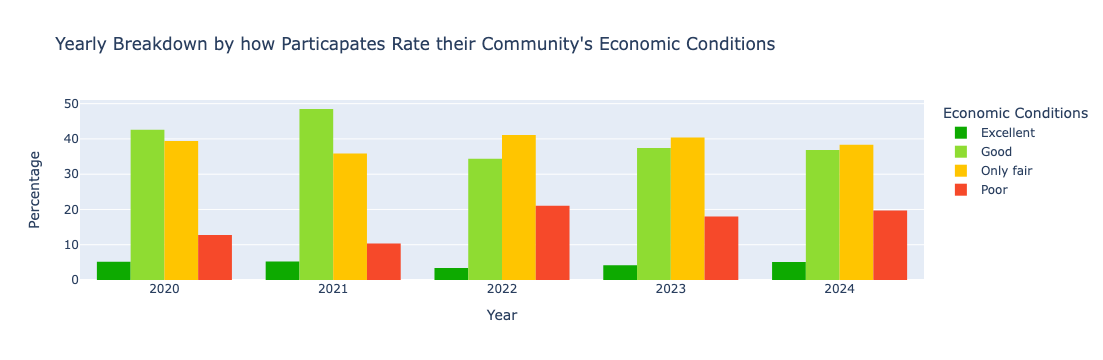

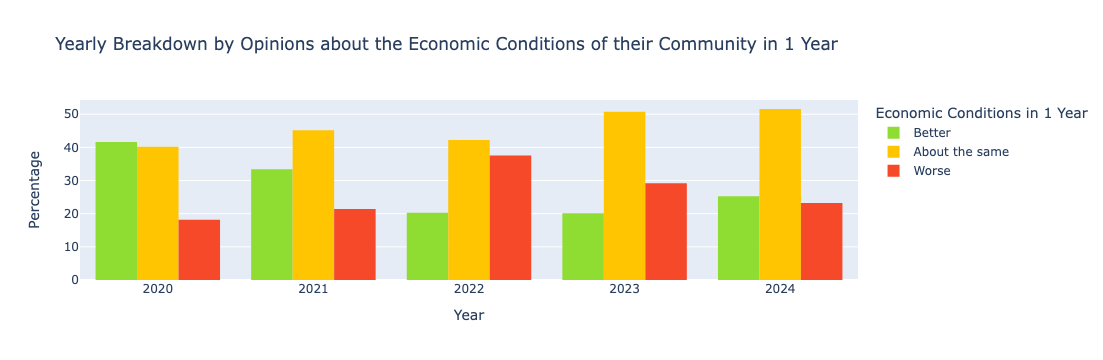

In [11]:
color_map = {
    'Excellent':"#0daa00",
    'Good':'#8fdc32',
    'Only fair':'#ffc500',
    'Poor':'#f6492a'
}
examine_changes('df_combined',None,'ECON1MOD','Economic Conditions',
                'Yearly Breakdown by how Particapates Rate their Community\'s Economic Conditions',1,[],color_map)

order = ['Better','About the same','Worse']
color_map = {
    'Better':"#8fdc32",
    'About the same':'#ffc500',
    'Worse':'#f6492a'
}
examine_changes('df_combined',None,'ECON1BMOD', 'Economic Conditions in 1 Year', 
                'Yearly Breakdown by Opinions about the Economic Conditions of their Community in 1 Year',1, order,color_map)


Opinions on the current economic conditions and estimated economic conditions in a year became more negative from 2021 to 2022. 

The percent of survey participants who believed the economy was going to get worse in a year increased from 21% to 37% from 2021 to 2022. The percent of survey participants who believed their community's economy was poor increased from 10% to 21%.

This could be caused by record-breaking inflation rates that occured towards the end of 2021 and throughout 2022. 

Source: [United States Inflation Rate](https://tradingeconomics.com/united-states/inflation-cpi)   

Next let's explore which groups are causing this increase in negative sentiment about the economy. 

In [12]:
# select all participants from 2021 and 2022 who believe their community's economic conditions is poor
df_econ_poor = sqldf(
    """
    SELECT *
    FROM df_combined
    WHERE ECON1MOD = 'Poor' AND
    YEAR IN (2021,2022)
    """
)
df_econ_poor.to_csv("CSV Files/result.csv",index=False)

# select all participants from 2021 and 2022 who believe their community's economic conditions will get worse
df_econ_worse = sqldf(
    """
    SELECT *
    FROM df_combined
    WHERE ECON1BMOD = 'Worse' AND
    YEAR IN (2021,2022)
    """
)
df_econ_worse.to_csv("CSV Files/result2.csv",index=False)

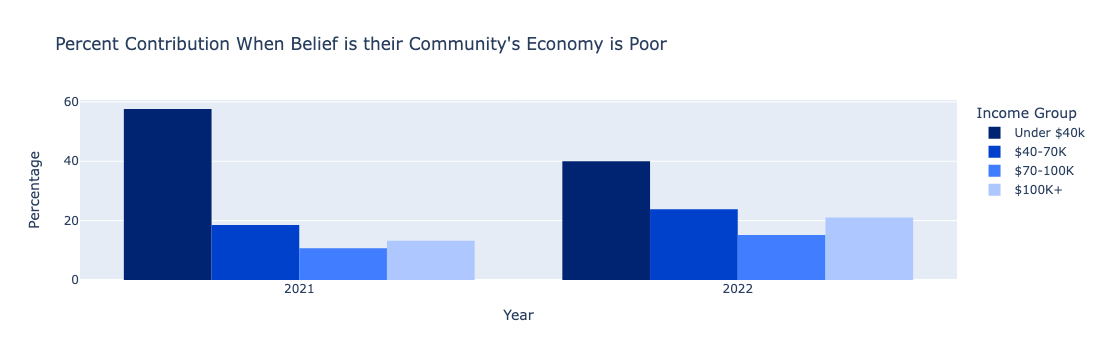

In [13]:
income_map1 = {
    'Under $40k':"#002471",
    '$40-70K':"#0041cb",
    '$70-100K':"#407dff",
    '$100K+':"#aec8ff"
}

examine_changes('df_econ_poor',None,'INCOME_GROUP','Income Group', 
                'Percent Contribution When Belief is their Community\'s Economy is Poor', 1,
                ['Under $40k','$40-70K','$70-100K','$100K+'],income_map1)

From this graph, we can see that the percent contribution of each income group to the total number of participants who thought their community's economy is poor is more balenced across the the income groups in 2022 than in 2021. This tells us that high inflation rates (and possibly other factors) affected higher income groups as well as low income groups. 

Interestingly, there are more people who believed their community's economy is poor in the group making more than 100,000 than the \$70-100K group.

   YEAR INCOME_GROUP  Count
0  2021       $100K+   1075
1  2021      $40-70K    830
2  2021     $70-100K    635
3  2021   Under $40k   1203
4  2022       $100K+   1190
5  2022      $40-70K    830
6  2022     $70-100K    653
7  2022   Under $40k   1133


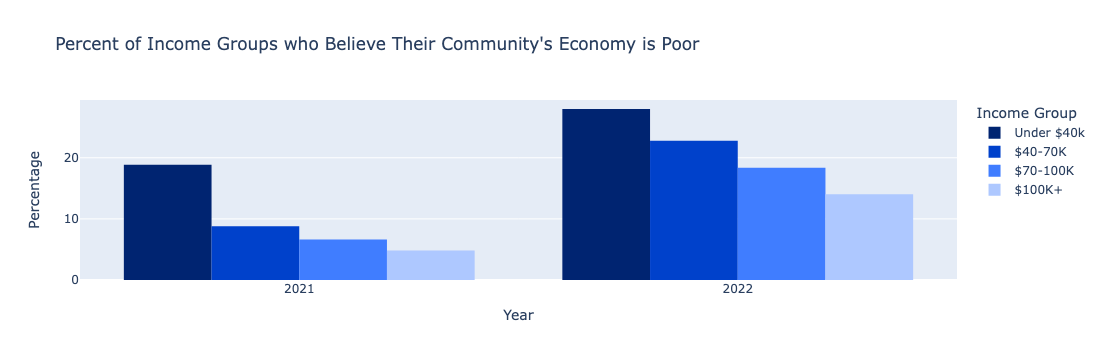

In [14]:
df_income_group_count = sqldf(
        """
        SELECT YEAR, INCOME_GROUP, COUNT(*) as Count
        FROM df_combined
        WHERE YEAR IN (2021,2022) AND INCOME_GROUP <> 'Other'
        GROUP BY YEAR, INCOME_GROUP
        """
)

print(df_income_group_count)

examine_changes('df_econ_poor',df_income_group_count,'INCOME_GROUP','Income Group', 
                'Percent of Income Groups who Believe Their Community\'s Economy is Poor', 2,
                ['Under $40k','$40-70K','$70-100K','$100K+'],income_map1)

The percent of each income group who thought their community's economic conditions is poor increased for all income groups showing us that high inflation is an issue for everyone regardless of income. 

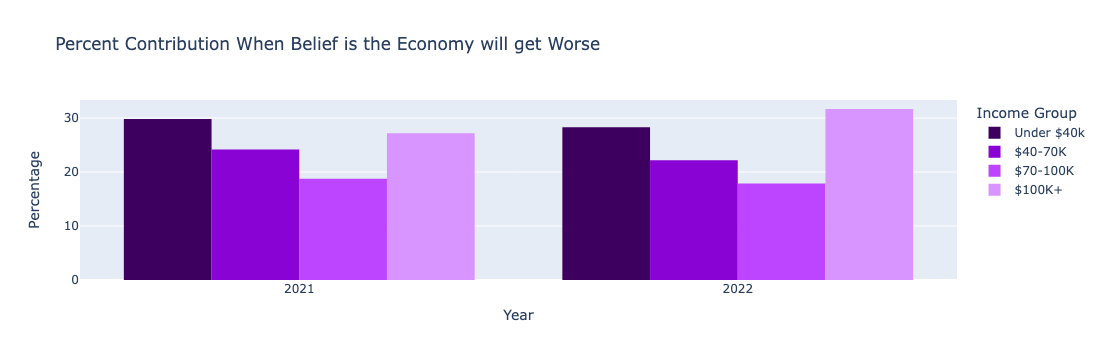

In [15]:
income_map2 = {
    'Under $40k':"#3d005e",
    '$40-70K':"#8a03d5",
    '$70-100K':"#bd45ff",
    '$100K+':"#d995ff"
}

examine_changes('df_econ_worse',None,'INCOME_GROUP','Income Group', 
                'Percent Contribution When Belief is the Economy will get Worse', 1,
                ['Under $40k','$40-70K','$70-100K','$100K+'],income_map2)

For the year 2022, participants who make $100K or more are the biggest contributor to the total number of participants who thought the economy was going to get worse and the second biggest for the year 2021. 

Theses percentages decrease as income increses (which is excepted) except for the highest income group. 

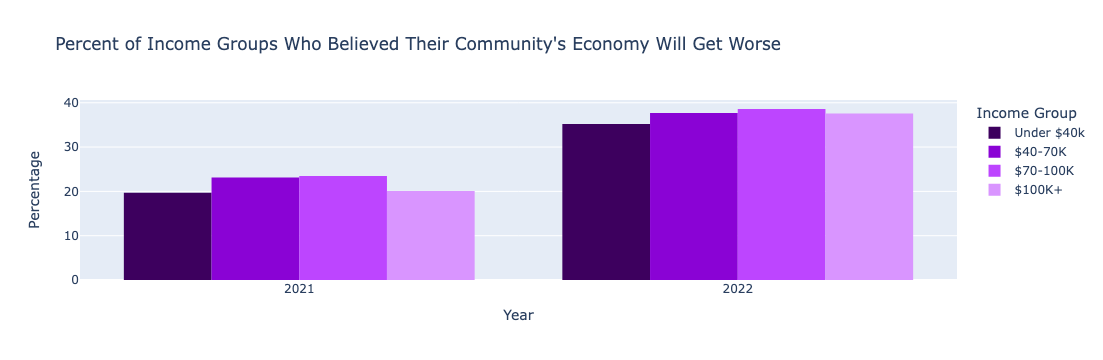

In [16]:
examine_changes('df_econ_worse', df_income_group_count, 'INCOME_GROUP','Income Group', 
                'Percent of Income Groups Who Believed Their Community\'s Economy Will Get Worse', 2,
                ['Under $40k','$40-70K','$70-100K','$100K+'],income_map2)

The percent of income groups who believe the economy will get worse increases for all group from 2021 to 2022. 

The group making 100,000 or more has the greatest increase. 20.1% of $100K\+ individuals thought the economy was going to get worse in 2021 which jumped to 37.6% in 2022.

   YEAR        PARTY  Count
0  2021     Democrat   1379
1  2021  Independent    945
2  2021   Republican   1146
3  2022     Democrat   1342
4  2022  Independent    950
5  2022   Republican   1260


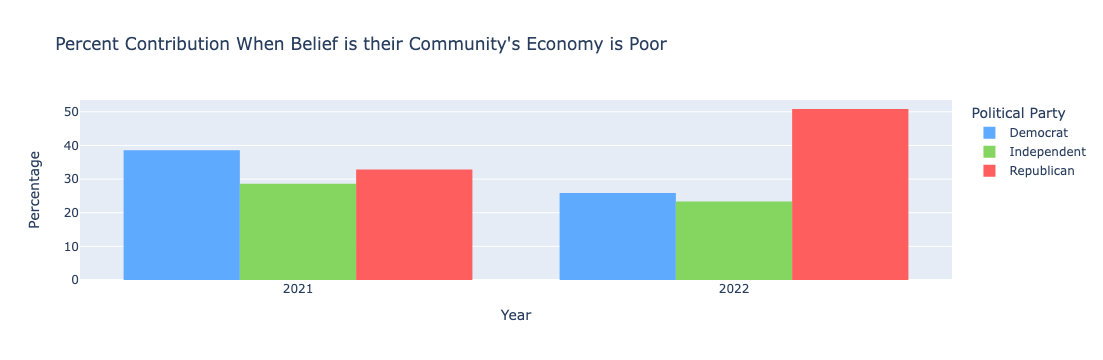

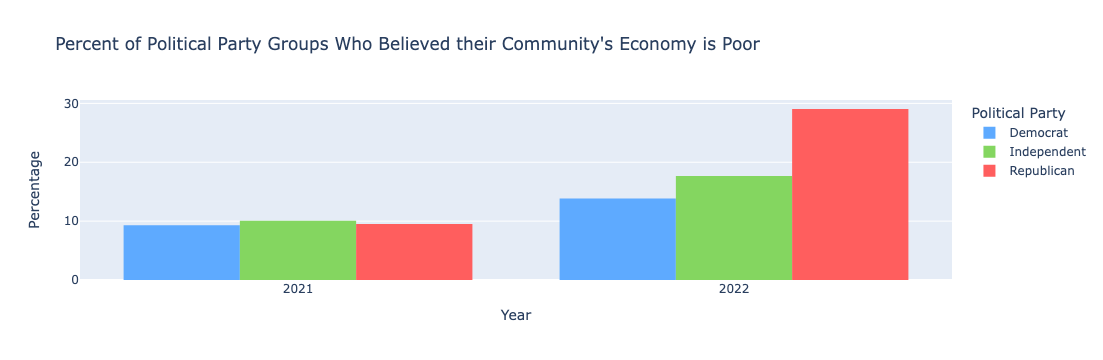

In [17]:
df_party_count = sqldf(
    """
    SELECT YEAR, PARTY, COUNT(*) as Count
    FROM df_combined
    WHERE YEAR IN (2021,2022) AND PARTY not in ('Something else', 'Refused')
    GROUP BY YEAR, PARTY
    """
)
print(df_party_count)

party_map = {
    'Democrat':"#5eaaff",
    'Republican':"#ff5e5e",
    'Independent':"#84d660"
}

examine_changes('df_econ_poor',None,'PARTY','Political Party', 
                'Percent Contribution When Belief is their Community\'s Economy is Poor',1,[],party_map)

examine_changes('df_econ_poor',df_party_count,'PARTY','Political Party', 
                'Percent of Political Party Groups Who Believed their Community\'s Economy is Poor',2,[],party_map)

In 2022, half of all participants who believed their community's economy is poor are Repubicans which increased from 32.8% in 2021. The percent of Republicans who believed their economy was poor increased from 9% to 29%. This could be because they are most likely to be unhappy with rising inflation rates under democrat Joe Biden leadership. 

## Exploring Trends and Correlations

In [18]:
def correlation(df, col_x, col_y, ord_x, ord_y, x_axis_title, title, color_map):
    # get count of each economy 
    df_change = sqldf(
        f"""
        SELECT 
            {col_x}, 
            {col_y}, 
            COUNT(*) as Count
        FROM {df}
        WHERE {col_y} NOT IN ("Refused", "",-1) AND {col_x} NOT IN ("Other","Refused")
        GROUP BY {col_x}, {col_y}
        """
    )
    # df_change = df_change.replace('Only Fair','Only fair')
    df_change['Percent'] = (df_change['Count'] / df_change.groupby(col_x)['Count'].transform('sum')) * 100
    df_change.to_csv("CSV Files/result.csv",index=False)

    fig = px.histogram(
        df_change,
        x=col_x,
        y='Percent',
        color=col_y,
        barmode='group',
        title=title,
        hover_data=['Count'],
        category_orders={
            col_x:ord_x,
            col_y:ord_y
        },
        color_discrete_map=color_map
    )
    fig.update_layout(legend_title_text='')
    fig.update_yaxes(title="Percentage").update_xaxes(title=x_axis_title).show()

### Income vs Religiousness

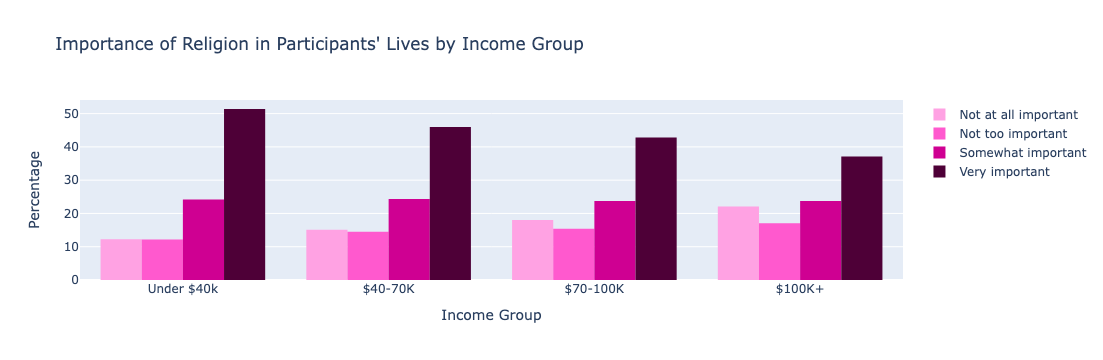

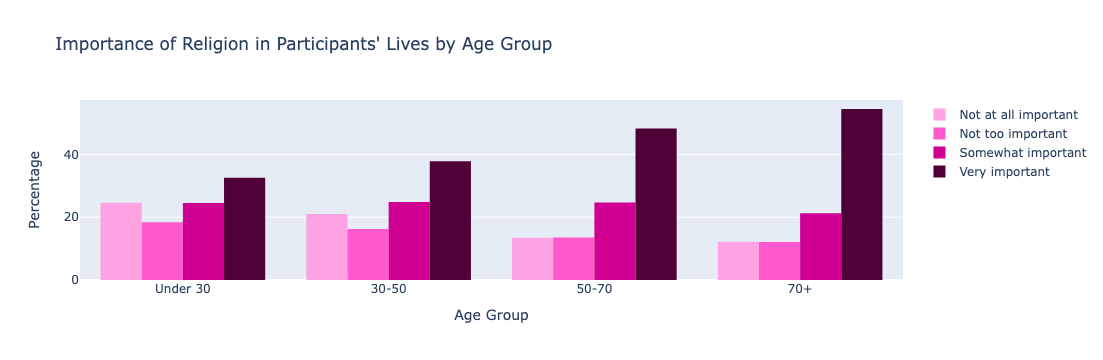

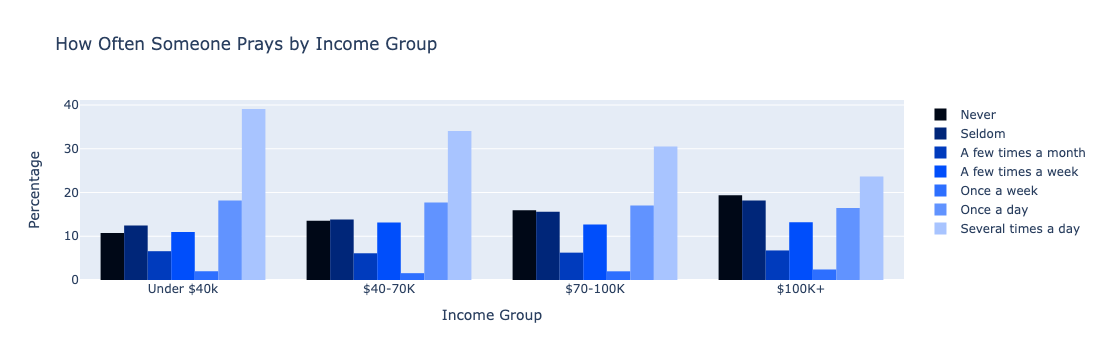

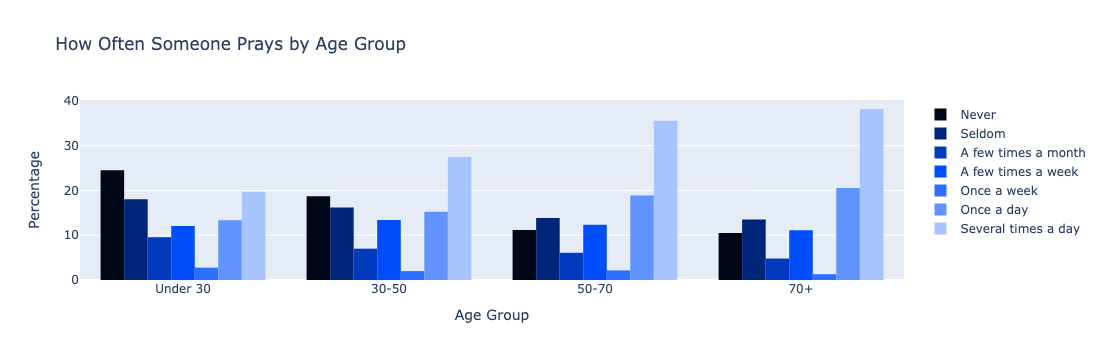

In [19]:
income_order = ['Under $40k','$40-70K','$70-100K','$100K+']
age_order = ['Under 30','30-50','50-70','70+']

relimp_map = {
    'Not at all important':'#ffa2e3',
    'Not too important':'#ff59ce',
    'Somewhat important':'#cf0092',
    'Very important':'#4e0037'
}

correlation('df_combined','INCOME_GROUP','RELIMP', income_order, [], 'Income Group',
            'Importance of Religion in Participants\' Lives by Income Group', relimp_map)

correlation('df_combined','AGE_GROUP','RELIMP', age_order, [], 'Age Group',
            'Importance of Religion in Participants\' Lives by Age Group', relimp_map)

pray_order = [
    'Never',
    'Seldom', 
    'A few times a month', 
    'A few times a week', 
    'Once a week', 
    'Once a day', 
    'Several times a day'
]

pray_map = {
    'Never':'#000817',
    'Seldom':'#002679', 
    'A few times a month':'#003bbd', 
    'A few times a week':'#004efb', 
    'Once a week':'#2d6fff', 
    'Once a day':'#6193ff', 
    'Several times a day':'#a8c4ff'
}

correlation('df_combined','INCOME_GROUP','PRAY', income_order, pray_order, 'Income Group',
    'How Often Someone Prays by Income Group', pray_map)

correlation('df_combined','AGE_GROUP','PRAY', age_order, pray_order, 'Age Group',
    'How Often Someone Prays by Age Group', pray_map)

Lower income and older individuals are more religious as measured by how often they pray and how important religion is in their lives. 

The percent of those who pray serveral times a day decrease with income and increase with age. More than half of those who make less than $40,000$ believe religion is very important in their lives. This percent drops to 37% for those that make over $100,000$.

### Income vs Social Media

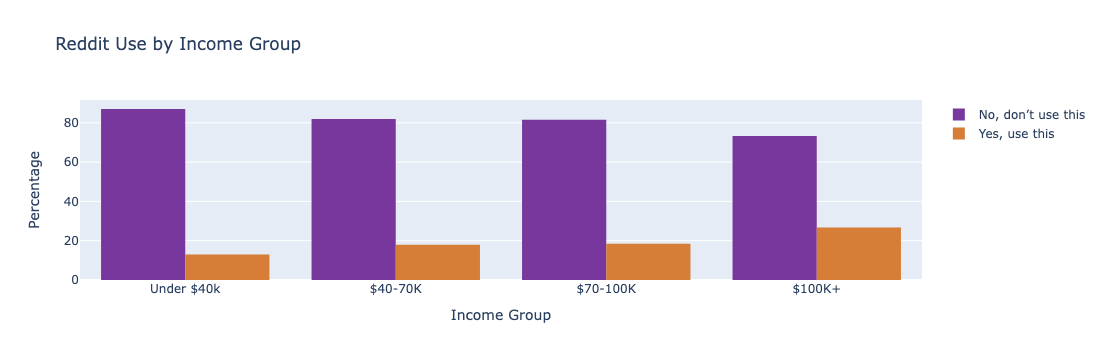

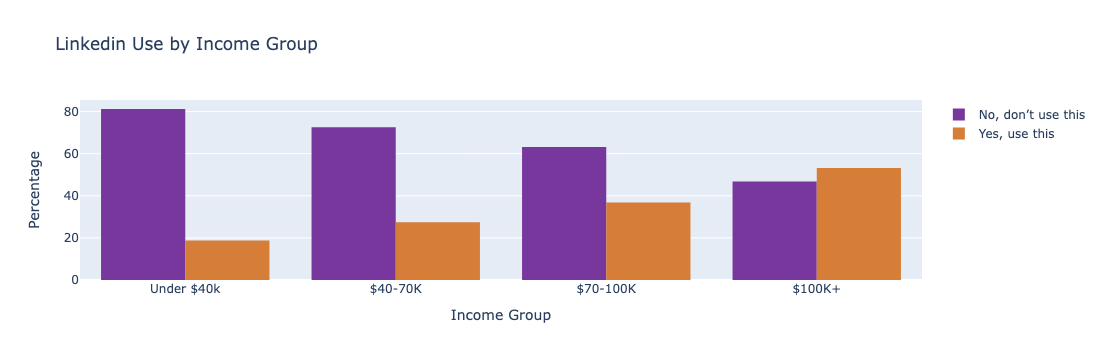

In [20]:
use_map = {
    'No, don’t use this':'#78379d',
    'Yes, use this':'#d67d37'
}

correlation('df_combined','INCOME_GROUP','REDDIT', income_order, [], 'Income Group','Reddit Use by Income Group', use_map)
correlation('df_combined','INCOME_GROUP','LINKEDIN', income_order, [], 'Income Group','Linkedin Use by Income Group', use_map)

Higher earning individuals are also more likely to use linkedin and reddit

In [1]:
#[5,3,2] returns 532 
# = 2*10^0 + 3*10^1 + 5*10^2 
# = 2 + 20 + 500 = 532
def form_number(digits):
    digits.reverse()
    number = 0
    for i in range(len(digits)):
        number += digits[i] * 10**i
    return number

print(form_number([5,3,2]))

532
